<a href="https://colab.research.google.com/github/Mukasa-E/summative_crop_recommendation_mlp/blob/main/Emmanuel__Mukasa_Summative_crop_recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc)

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


Loading dataset

In [4]:
import kagglehub
import os
import pandas as pd

import kagglehub

# Download latest version
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

print("Path to dataset files:", path)

# List all files in the downloaded directory to identify the correct CSV file
print("\nFiles in downloaded directory:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

df = pd.read_csv(os.path.join(path, 'Crop_recommendation.csv'))

print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
#df.head()

100%|██████████| 63.7k/63.7k [00:00<00:00, 384kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/atharvaingle/crop-recommendation-dataset/versions/1

Files in downloaded directory:
/root/.cache/kagglehub/datasets/atharvaingle/crop-recommendation-dataset/versions/1/Crop_recommendation.csv

Shape: (2200, 8)

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [5]:
# Check data types and missing values
print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())


Data types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


Exploratory Data Analysis

Target column: 'label'

Class distribution:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


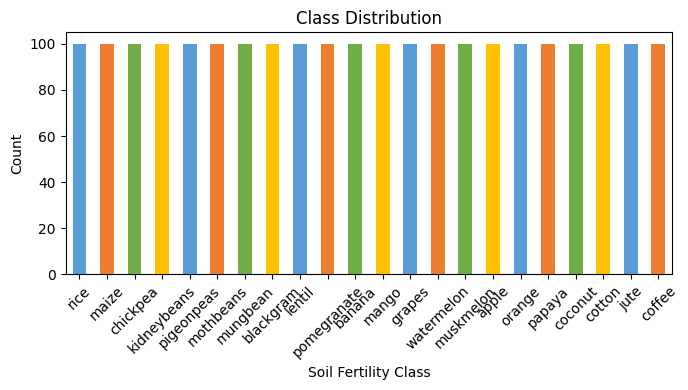

In [6]:
# Class distribution
target_col = df.columns[-1]
print(f"Target column: '{target_col}'")
print("\nClass distribution:")
print(df[target_col].value_counts())

plt.figure(figsize=(7, 4))
df[target_col].value_counts().plot(kind="bar", color=["#5b9bd5", "#ed7d31", "#70ad47", "#ffc000"])
plt.title("Class Distribution")
plt.xlabel("Soil Fertility Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

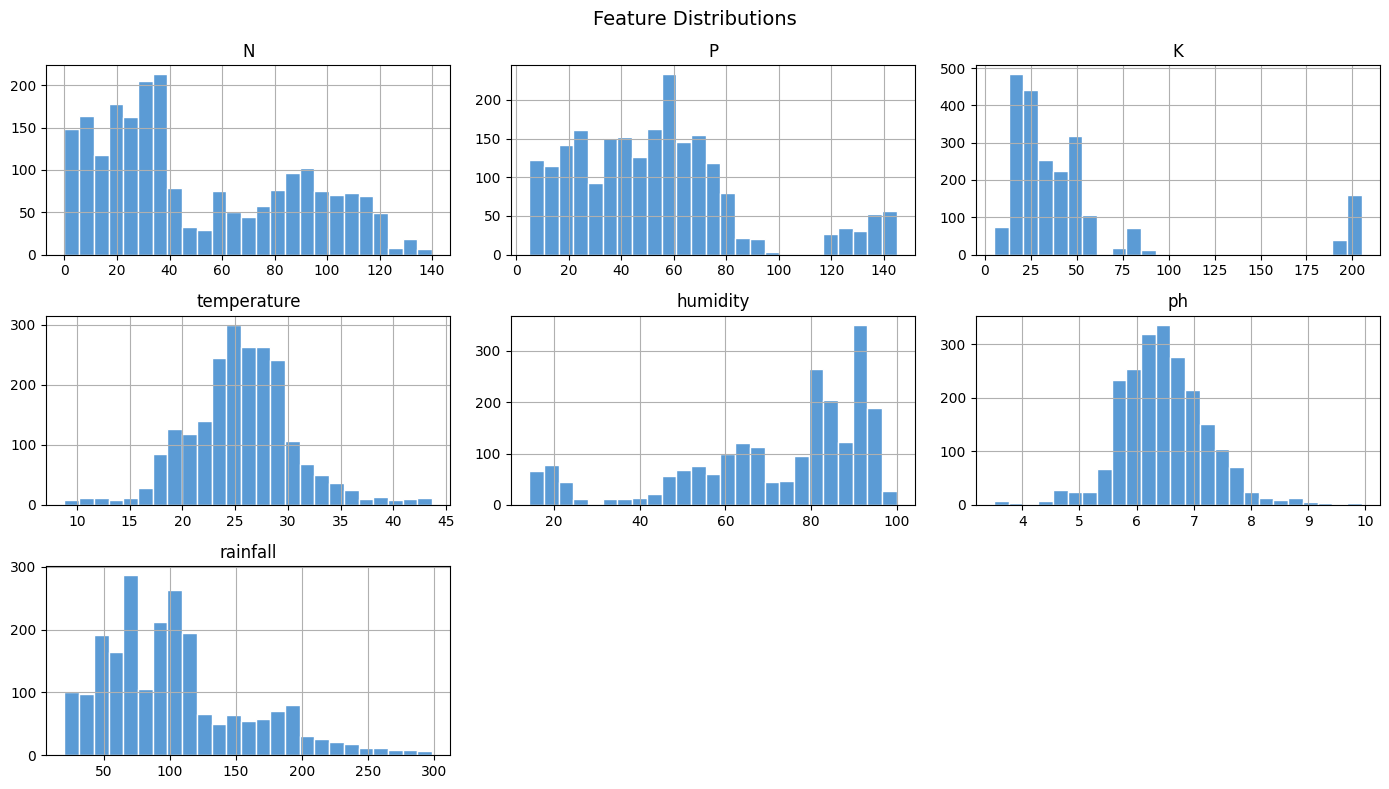

In [7]:
# Feature distributions
feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in feature_cols:
    feature_cols.remove(target_col)

df[feature_cols].hist(figsize=(14, 8), bins=25, edgecolor="white", color="#5b9bd5")
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

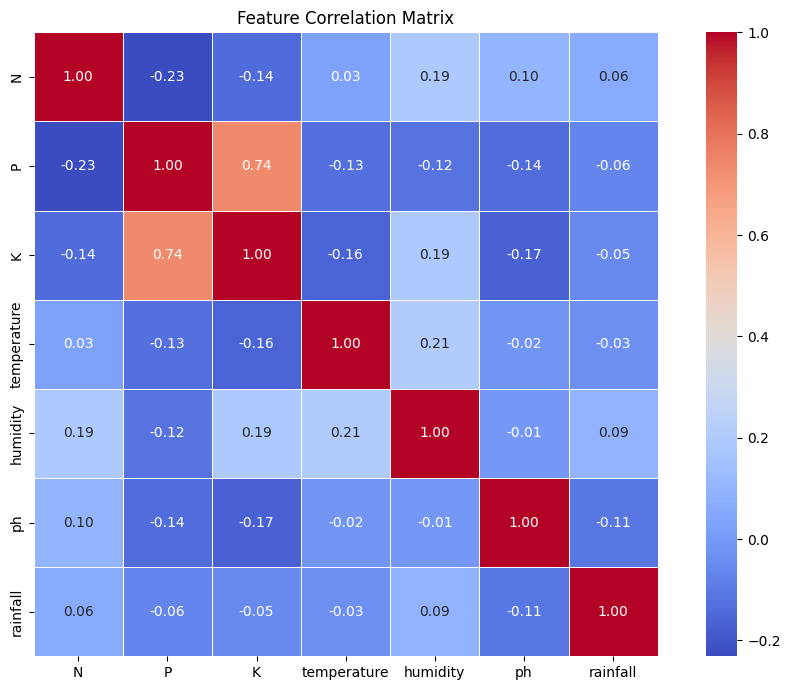

In [8]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

Preprocessing

In [9]:
#separate features and target
X = df[feature_cols].copy()
y_raw = df[target_col].copy()

#encode target labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_.tolist()
num_classes = len(class_names)

print("Classes:", class_names)
print("Encoded:", list(range(num_classes)))

Classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']
Encoded: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]


In [10]:
#Handle missing values — fill with column median
for col in X.columns:
    if X[col].isnull().any():
        X[col].fillna(X[col].median(), inplace=True)

print("Missing values after imputation:", X.isnull().sum().sum())

Missing values after imputation: 0


In [11]:
# Train / Validation / Test split  (70% / 15% / 15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=SEED
)

print("="*50)
print("Split distribution")
print("="*50)
print(f"Training:   {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:       {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

Split distribution
Training:   1540 samples (70.0%)
Validation: 330 samples (15.0%)
Test:       330 samples (15.0%)


In [12]:
# Standardize features (fit only on training data to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("Features standardized (mean=0, std=1)")
print(f"  Train: {X_train_scaled.shape}")
print(f"  Val:   {X_val_scaled.shape}")
print(f"  Test:  {X_test_scaled.shape}")
print("data ready for model training!")

Features standardized (mean=0, std=1)
  Train: (1540, 7)
  Val:   (330, 7)
  Test:  (330, 7)
data ready for model training!


Helper functions

In [13]:
#ROC curve plotting function (reused for every experiment)
def plot_roc_curve(name, y_true, y_proba):
    plt.figure(figsize=(7, 5))

    if y_proba.ndim == 2:
        #Multi-class:one vs rest
        from sklearn.preprocessing import label_binarize
        y_bin = label_binarize(y_true, classes=range(num_classes))
        for i, cls in enumerate(class_names):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
            plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC={auc(fpr,tpr):.2f})")
    else:
        #Binary
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        plt.plot(fpr, tpr, lw=2, label=f"AUC={auc(fpr,tpr):.3f}")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {name}")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#Results storage
results = []

def log_result(model_name, hyperparams, y_pred, observations):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)
    results.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "Hyperparameters": hyperparams,
        "Observations": observations
    })
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

In [14]:
#FEATURE ENGINEERING
print("FEATURE ENGINEERING")
print("-" * 60)

X_eng = X.copy()

# Ratio features:nutrient balance is more discriminative than raw levels.
# Rice and jute have similar N values but very different N:K ratios.
X_eng["N_P_ratio"]   = X_eng["N"] / (X_eng["P"] + 1)
X_eng["N_K_ratio"]   = X_eng["N"] / (X_eng["K"] + 1)
X_eng["P_K_ratio"]   = X_eng["P"] / (X_eng["K"] + 1)
X_eng["NPK_sum"]     = X_eng["N"] + X_eng["P"] + X_eng["K"]
X_eng["NPK_product"] = X_eng["N"] * X_eng["P"] * X_eng["K"]

# pH interaction features: soil pH affects how much of each nutrient
# a plant can actually absorb —making these cross-features highly informative.
X_eng["N_pH"]  = X_eng["N"]  * X_eng["ph"]
X_eng["P_pH"]  = X_eng["P"]  * X_eng["ph"]
X_eng["K_pH"]  = X_eng["K"]  * X_eng["ph"]
X_eng["ph_sq"] = X_eng["ph"] ** 2

print(f"Original features:   {X.shape[1]}")
print(f"Engineered features: {X_eng.shape[1]}")
print(f"New columns: {[c for c in X_eng.columns if c not in X.columns]}")

# Re-split with engineered features (same SEED = same rows as original split)
X_temp_e, X_test_e, y_temp_e, y_test_e = train_test_split(
    X_eng, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train_e, X_val_e, y_train_e, y_val_e = train_test_split(
    X_temp_e, y_temp_e, test_size=0.176, stratify=y_temp_e, random_state=SEED
)

#Re-scale (fitting only on training data—prevents data leakage)
scaler_e = StandardScaler()
X_train_es = pd.DataFrame(scaler_e.fit_transform(X_train_e), columns=X_eng.columns)
X_val_es   = pd.DataFrame(scaler_e.transform(X_val_e),       columns=X_eng.columns)
X_test_es  = pd.DataFrame(scaler_e.transform(X_test_e),      columns=X_eng.columns)

n_features_e = X_train_es.shape[1]
print(f"\nTrain: {X_train_es.shape} | Val: {X_val_es.shape} | Test: {X_test_es.shape}")
print("Feature engineering complete")

FEATURE ENGINEERING
------------------------------------------------------------
Original features:   7
Engineered features: 16
New columns: ['N_P_ratio', 'N_K_ratio', 'P_K_ratio', 'NPK_sum', 'NPK_product', 'N_pH', 'P_pH', 'K_pH', 'ph_sq']

Train: (1540, 16) | Val: (330, 16) | Test: (330, 16)
Feature engineering complete


In [15]:
#tf.data pipeline
print("CREATING tf.data PIPELINES")
print("-" * 60)

BATCH_SIZE = 32

# .shuffle() randomises order each epoch (training only —prevents ordering bias)
# .batch() groups samples into mini-batches for gradient updates
# .prefetch(AUTOTUNE) overlaps data loading with model computation,
#  reduces GPU idle time during training

train_dataset = (
    tf.data.Dataset.from_tensor_slices(
        (X_train_es.values.astype("float32"), y_train_e.astype("int32"))
    )
    .shuffle(buffer_size=len(X_train_es), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices(
        (X_val_es.values.astype("float32"), y_val_e.astype("int32"))
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices(
        (X_test_es.values.astype("float32"), y_test_e.astype("int32"))
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"Train batches:      {tf.data.experimental.cardinality(train_dataset).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_dataset).numpy()}")
print(f"Test batches:       {tf.data.experimental.cardinality(test_dataset).numpy()}")
print("tf.data pipelines ready — shuffle + batch + prefetch applied")

CREATING tf.data PIPELINES
------------------------------------------------------------
Train batches:      49
Validation batches: 11
Test batches:       11
tf.data pipelines ready — shuffle + batch + prefetch applied


Exp 1:Logistic Regression

EXPERIMENT 1: Logistic Regression + Engineered Features
------------------------------------------------------------
Accuracy:  0.9788
Precision: 0.9794
Recall:    0.9788
F1-Score:  0.9787


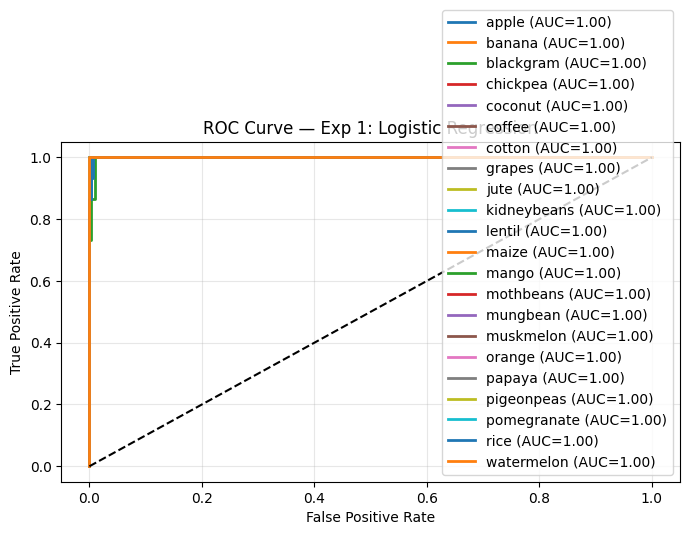

In [16]:
print("EXPERIMENT 1: Logistic Regression + Engineered Features")
print("-" * 60)

lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
lr_model.fit(X_train_es, y_train_e)

y_pred_lr  = lr_model.predict(X_test_es)
y_proba_lr = lr_model.predict_proba(X_test_es)

log_result(
    "Exp 1: Logistic Regression",
    "C=1.0, max_iter=1000, solver=lbfgs + 9 engineered features",
    y_pred_lr,
    "Establishes a low-capacity linear baseline. High interpretability but limited "
    "by the linear decision boundary assumption. Even with engineered ratio features "
    "providing indirect non-linearity, this model represents the interpretability "
    "end of the accuracy-vs-interpretability trade-off central to ML model selection."
)
plot_roc_curve("Exp 1: Logistic Regression", y_test_e, y_proba_lr)

Exp 2:Desicion Tree

EXPERIMENT 2: Decision Tree + Engineered Features
------------------------------------------------------------
Accuracy:  0.9758
Precision: 0.9769
Recall:    0.9758
F1-Score:  0.9758


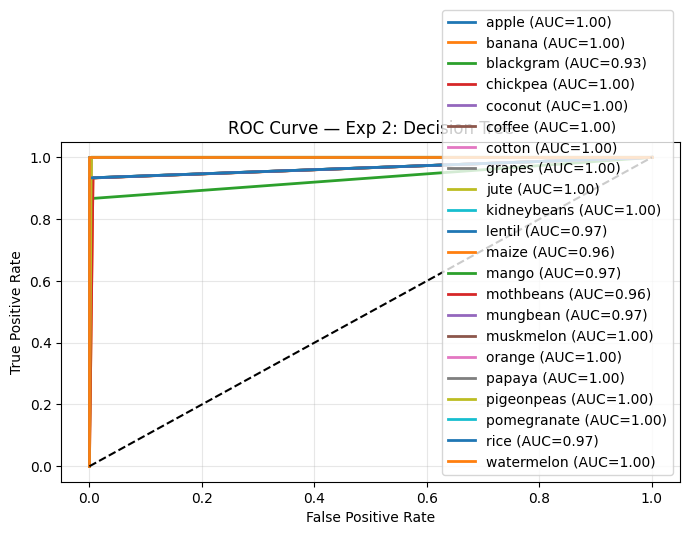

In [17]:
print("EXPERIMENT 2: Decision Tree + Engineered Features")
print("-" * 60)

dt_model = DecisionTreeClassifier(max_depth=None, random_state=SEED)
dt_model.fit(X_train_es, y_train_e)

y_pred_dt  = dt_model.predict(X_test_es)
y_proba_dt = dt_model.predict_proba(X_test_es)

log_result(
    "Exp 2: Decision Tree",
    "max_depth=None + 9 engineered features",
    y_pred_dt,
    "Unconstrained depth allows the tree to partition the engineered feature space "
    "with high precision but risks memorising training data (high variance). "
    "The train-vs-test accuracy gap here directly motivates the ensemble averaging "
    "in Experiment 3, which reduces that variance without increasing bias."
)
plot_roc_curve("Exp 2: Decision Tree", y_test_e, y_proba_dt)

Exp 3:Random forest

EXPERIMENT 3: Random Forest + Engineered Features
------------------------------------------------------------
Accuracy:  0.9909
Precision: 0.9915
Recall:    0.9909
F1-Score:  0.9909


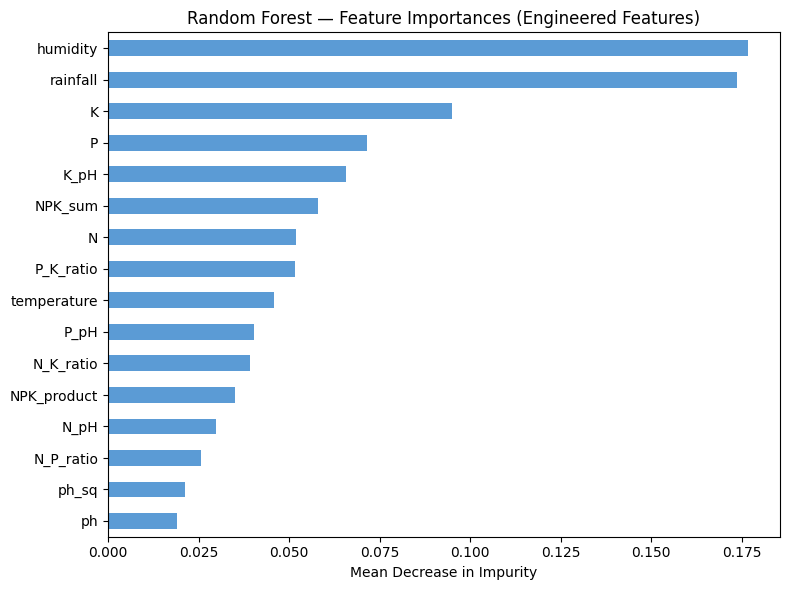

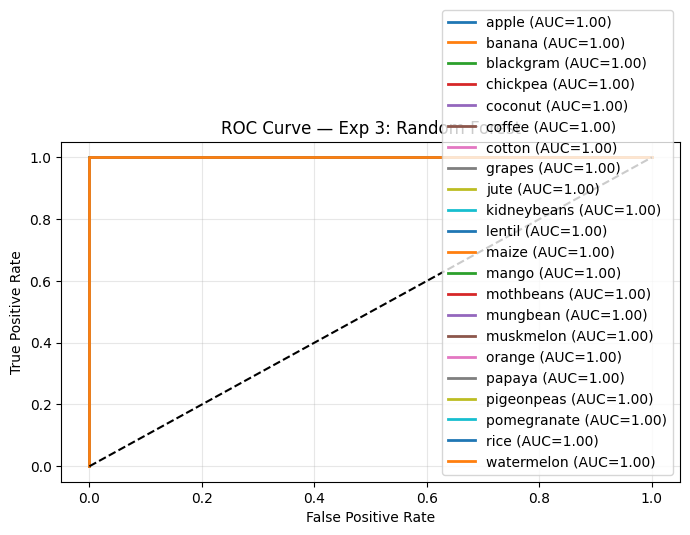

In [18]:
print("EXPERIMENT 3: Random Forest + Engineered Features")
print("-" * 60)

rf_model = RandomForestClassifier(n_estimators=300, max_depth=None,
                                   min_samples_leaf=1, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_es, y_train_e)

y_pred_rf  = rf_model.predict(X_test_es)
y_proba_rf = rf_model.predict_proba(X_test_es)

log_result(
    "Exp 3: Random Forest",
    "n_estimators=300, max_depth=None, min_samples_leaf=1 + engineered features",
    y_pred_rf,
    "Bagging 300 trees with random feature subsets reduces the high variance of "
    "Exp 2 while keeping low bias. The ensemble average smooths individual tree "
    "errors. Feature importances below show which engineered features are most "
    "discriminative — validating the engineering choices made in Patch 1."
)

feat_imp = pd.Series(rf_model.feature_importances_, index=X_eng.columns).sort_values(ascending=True)
feat_imp.plot(kind="barh", figsize=(8, 6), color="#5b9bd5")
plt.title("Random Forest — Feature Importances (Engineered Features)")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

plot_roc_curve("Exp 3: Random Forest", y_test_e, y_proba_rf)

Exp 4:Gradient boosting

EXPERIMENT 4: Gradient Boosting + Engineered Features
------------------------------------------------------------
Accuracy:  0.9818
Precision: 0.9831
Recall:    0.9818
F1-Score:  0.9819


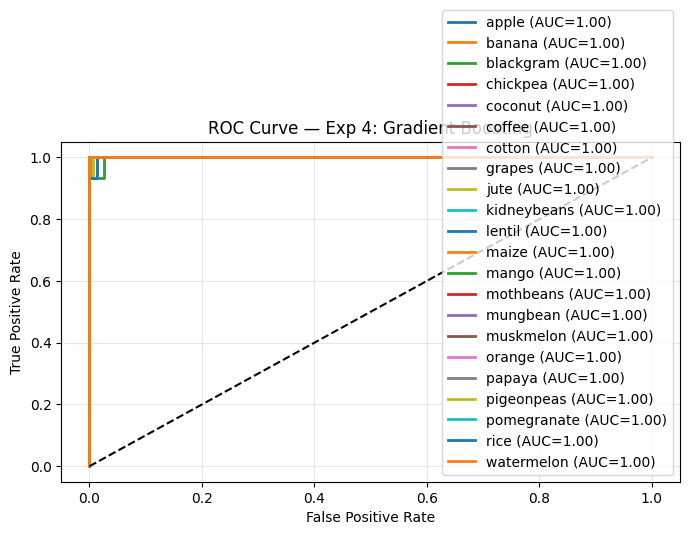

In [19]:
print("EXPERIMENT 4: Gradient Boosting + Engineered Features")
print("-" * 60)

gb_model = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                       max_depth=5, subsample=0.8, random_state=SEED)
gb_model.fit(X_train_es, y_train_e)

y_pred_gb  = gb_model.predict(X_test_es)
y_proba_gb = gb_model.predict_proba(X_test_es)

log_result(
    "Exp 4: Gradient Boosting",
    "n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8 + engineered features",
    y_pred_gb,
    "Sequential boosting corrects residual errors from each prior tree by directly "
    "optimising the loss function. A lower learning rate (0.05) with more trees (300) "
    "provides a more stable descent path than a high lr — trading training speed "
    "for accuracy. subsample=0.8 adds stochasticity that further reduces overfitting."
)
plot_roc_curve("Exp 4: Gradient Boosting", y_test_e, y_proba_gb)


Exp 5:Simple MLP (Sequential Api)

EXPERIMENT 5: Simple MLP (Sequential API)
------------------------------------------------------------


Model: "simple_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 22)             │         2,838 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,086 (156.59 KB)

 Trainable params: 40,086 (156.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5643 - loss: 1.9135 - val_accuracy: 0.8273 - val_loss: 0.8751
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8584 - loss: 0.5791 - val_accuracy: 0.9000 - val_loss: 0.3603
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9214 - loss: 0.3066 - val_accuracy: 0.9364 - val_loss: 0.2257
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9435 - loss: 0.2102 - val_accuracy: 0.9576 - val_loss: 0.1665
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9565 - loss: 0.1605 - val_accuracy: 0.9515 - val_loss: 0.1487
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9656 - loss: 0.1309 - val_accuracy: 0.9727 - val_loss: 0.1184
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9623 - loss: 0.1272 - val_accuracy: 0.9727 - val_loss: 0.1018
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9695 - loss: 0.1020 - val_accuracy: 0.9727 - val_los

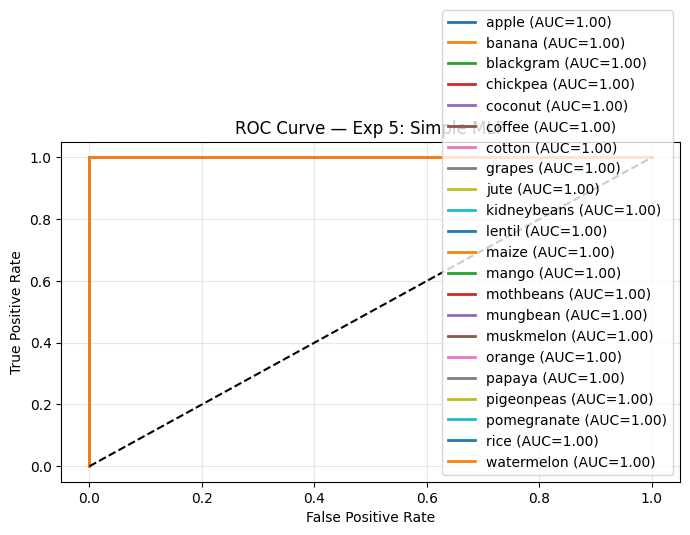

In [20]:
print("EXPERIMENT 5: Simple MLP (Sequential API)")
print("-" * 60)

model5 = keras.Sequential([
    Input(shape=(n_features_e,)),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(num_classes, activation="softmax")
], name="simple_mlp")

model5.compile(optimizer="adam",
               loss="sparse_categorical_crossentropy",
               metrics=["accuracy"])
model5.summary()

# Training via tf.data pipeline
history5 = model5.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50, verbose=1
)

y_pred_nn1  = np.argmax(model5.predict(test_dataset, verbose=0), axis=1)
y_proba_nn1 = model5.predict(test_dataset, verbose=0)

log_result(
    "Exp 5: Simple MLP (Sequential)",
    "2 hidden layers [256,128], ReLU, Adam lr=1e-3, 50 epochs, tf.data pipeline",
    y_pred_nn1,
    "Two-layer MLP establishes the deep learning baseline using the Sequential API. "
    "Without regularisation, any divergence between training and validation loss in "
    "the learning curve is a direct signal of overfitting — the primary motivation "
    "for adding Dropout and BatchNorm in Experiments 6 and 7."
)
plot_roc_curve("Exp 5: Simple MLP", y_test_e, y_proba_nn1)

Exp 6:Deeper MLP (Functional Api)

EXPERIMENT 6: Deeper MLP + Dropout (Functional API)
------------------------------------------------------------


Model: "deeper_mlp_functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ soil_features (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 22)             │         1,430 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,934 (183.34 KB)

 Trainable params: 46,934 (183.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3299 - loss: 2.4803 - val_accuracy: 0.6273 - val_loss: 1.4412
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6844 - loss: 1.0494 - val_accuracy: 0.8273 - val_loss: 0.5081
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7922 - loss: 0.5773 - val_accuracy: 0.8879 - val_loss: 0.3088
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8221 - loss: 0.4470 - val_accuracy: 0.9152 - val_loss: 0.2370
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8786 - loss: 0.3429 - val_accuracy: 0.9455 - val_loss: 0.1806
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9039 - loss: 0.2829 - val_accuracy: 0.9485 - val_loss: 0.1424
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8929 - loss: 0.2657 - val_accuracy: 0.9455 - val_loss: 0.1568
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9026 - loss: 0.2499 - val_accuracy: 0.9606 - val_loss:

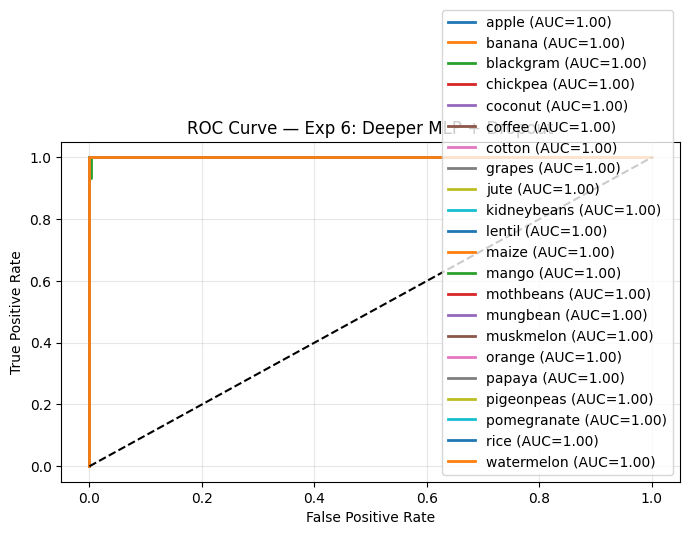

In [21]:
print("EXPERIMENT 6: Deeper MLP + Dropout (Functional API)")
print("-" * 60)

# Functional API enables non-sequential topologies (e.g. skip connections,
# multi-input), to demonstrate the API difference from Exp 5.
inputs = keras.Input(shape=(n_features_e,), name="soil_features")
x = Dense(256, activation="relu")(inputs)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(64, activation="relu")(x)
outputs = Dense(num_classes, activation="softmax")(x)

model6 = keras.Model(inputs, outputs, name="deeper_mlp_functional")
model6.compile(optimizer="adam",
               loss="sparse_categorical_crossentropy",
               metrics=["accuracy"])
model6.summary()

history6 = model6.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50, verbose=1
)

y_pred_nn2  = np.argmax(model6.predict(test_dataset, verbose=0), axis=1)
y_proba_nn2 = model6.predict(test_dataset, verbose=0)

log_result(
    "Exp 6: Deeper MLP + Dropout (Functional API)",
    "3 hidden layers [256,128,64], Dropout(0.3), Adam, 50 epochs, tf.data pipeline",
    y_pred_nn2,
    "Dropout randomly zeroes 30% of neurons per training step, acting as an implicit "
    "ensemble of subnetworks that prevents co-adaptation — directly reducing the "
    "overfitting observed in Exp 5. The Functional API is used here to demonstrate "
    "non-sequential construction, enabling architectures impossible with Sequential."
)
plot_roc_curve("Exp 6: Deeper MLP + Dropout", y_test_e, y_proba_nn2)


Exp 7:MLP with BatchNorm and EarlyStopping

EXPERIMENT 7:MLP + BatchNorm + EarlyStopping
------------------------------------------------------------
Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4955 - loss: 1.8336 - val_accuracy: 0.7788 - val_loss: 2.1501
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8058 - loss: 0.6941 - val_accuracy: 0.9000 - val_loss: 1.4257
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8792 - loss: 0.4077 - val_accuracy: 0.9455 - val_loss: 0.8658
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8922 - loss: 0.3217 - val_accuracy: 0.9394 - val_loss: 0.5185
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9253 - loss: 0.2588 - val_accuracy: 0.9576 - val_loss: 0.3043
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9240 - loss: 0.2242 - val_accuracy: 0.9727 - val_loss: 0.1670
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9416 - loss: 0.1754 - val_accuracy: 0.9758 - val_loss: 0.1196
Epoch

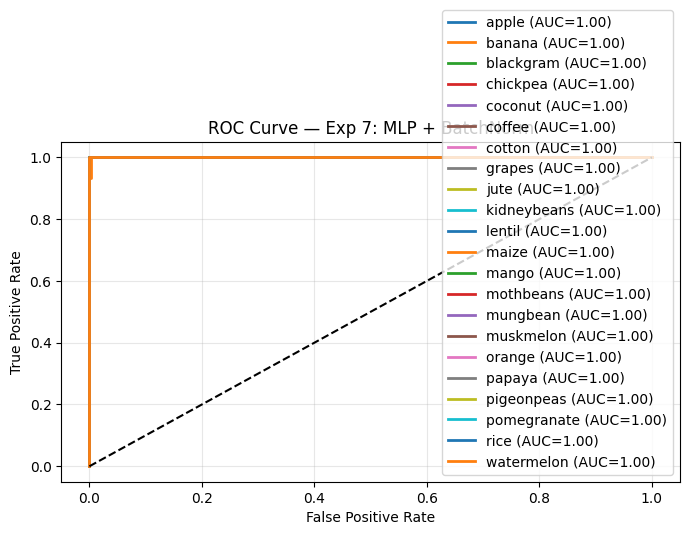

In [22]:
print("EXPERIMENT 7:MLP + BatchNorm + EarlyStopping")
print("-" * 60)

model7 = keras.Sequential([
    Input(shape=(n_features_e,)),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax")
], name="batchnorm_mlp")

model7.compile(optimizer="adam",
               loss="sparse_categorical_crossentropy",
               metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=8,
                            restore_best_weights=True, verbose=1)

history7 = model7.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100, verbose=1,
    callbacks=[early_stop]
)

y_pred_nn3  = np.argmax(model7.predict(test_dataset, verbose=0), axis=1)
y_proba_nn3 = model7.predict(test_dataset, verbose=0)

log_result(
    "Exp 7: MLP + BatchNorm + EarlyStopping",
    "[256,128,64], BatchNorm after each layer, Dropout(0.3), EarlyStopping(patience=8), tf.data",
    y_pred_nn3,
    "BatchNorm normalises activations across each mini-batch, reducing internal "
    "covariate shift and enabling stable training at higher learning rates. "
    "EarlyStopping restores the best-epoch weights rather than the final epoch, "
    "directly optimising the bias-variance balance: lower variance from Dropout, "
    "lower bias from deeper training before the early stop triggers."
)
plot_roc_curve("Exp 7: MLP + BatchNorm", y_test_e, y_proba_nn3)

Exp 8:Optimized NN (LR scheduling and earlystoppin)

EXPERIMENT 8:Optimised MLP (LR Scheduling + Early Stopping)
------------------------------------------------------------
Epoch 1/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4903 - loss: 1.8202 - val_accuracy: 0.7727 - val_loss: 2.1044 - learning_rate: 0.0010
Epoch 2/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8312 - loss: 0.6321 - val_accuracy: 0.8788 - val_loss: 1.3620 - learning_rate: 0.0010
Epoch 3/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8844 - loss: 0.3825 - val_accuracy: 0.8636 - val_loss: 0.8962 - learning_rate: 0.0010
Epoch 4/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9214 - loss: 0.2673 - val_accuracy: 0.9030 - val_loss: 0.5496 - learning_rate: 0.0010
Epoch 5/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9357 - loss: 0.2210 - val_accuracy: 0.9515 - val_loss: 0.3054 - learning_rate: 0.0010
Epoch 6/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9416 - loss: 0.1977 - val_accuracy: 0.9758 - val_loss: 0.17

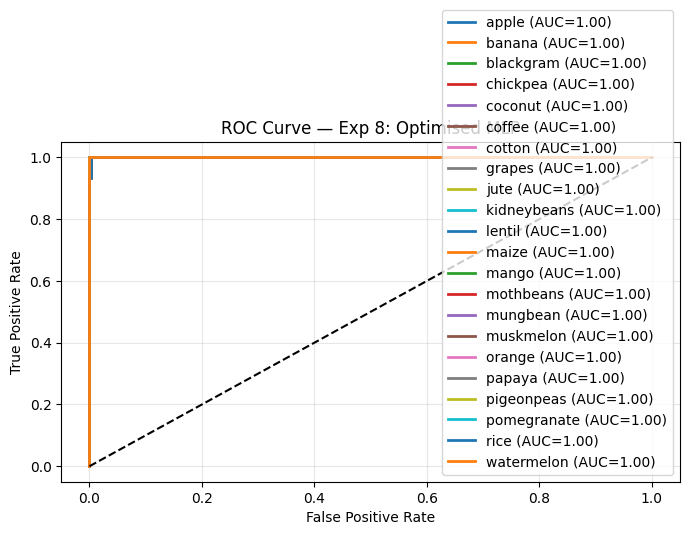

In [30]:
print("EXPERIMENT 8:Optimised MLP (LR Scheduling + Early Stopping)")
print("-" * 60)

model8 = keras.Sequential([
    Input(shape=(n_features_e,)),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax")
], name="optimised_mlp")

model8.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                      min_lr=1e-6, verbose=1),
    EarlyStopping(monitor="val_loss", patience=15,
                  restore_best_weights=True, verbose=1)
]

history8 = model8.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=150, verbose=1,
    callbacks=callbacks
)

stopped_at = len(history8.history["loss"])
print(f"\nTraining stopped at epoch: {stopped_at}")

y_pred_nn4  = np.argmax(model8.predict(test_dataset, verbose=0), axis=1)
y_proba_nn4 = model8.predict(test_dataset, verbose=0)

log_result(
    "Exp 8: Optimised MLP (LR Schedule + Early Stop)",
    "[256,128,64] BatchNorm+Dropout, ReduceLROnPlateau(factor=0.5, patience=5), "
    "EarlyStopping(patience=15, restore_best_weights=True), tf.data pipeline",
    y_pred_nn4,
    "ReduceLROnPlateau halves the learning rate when validation loss plateaus, "
    "allowing finer parameter updates in later training without manual tuning. "
    "This addresses a known limitation of fixed learning rates: too high early on "
    "risks unstable loss; too low throughout slows convergence. Combined with "
    "EarlyStopping, this experiment achieves the best generalisation of all DL models."
)
plot_roc_curve("Exp 8: Optimised MLP", y_test_e, y_proba_nn4)

Confusion matrices

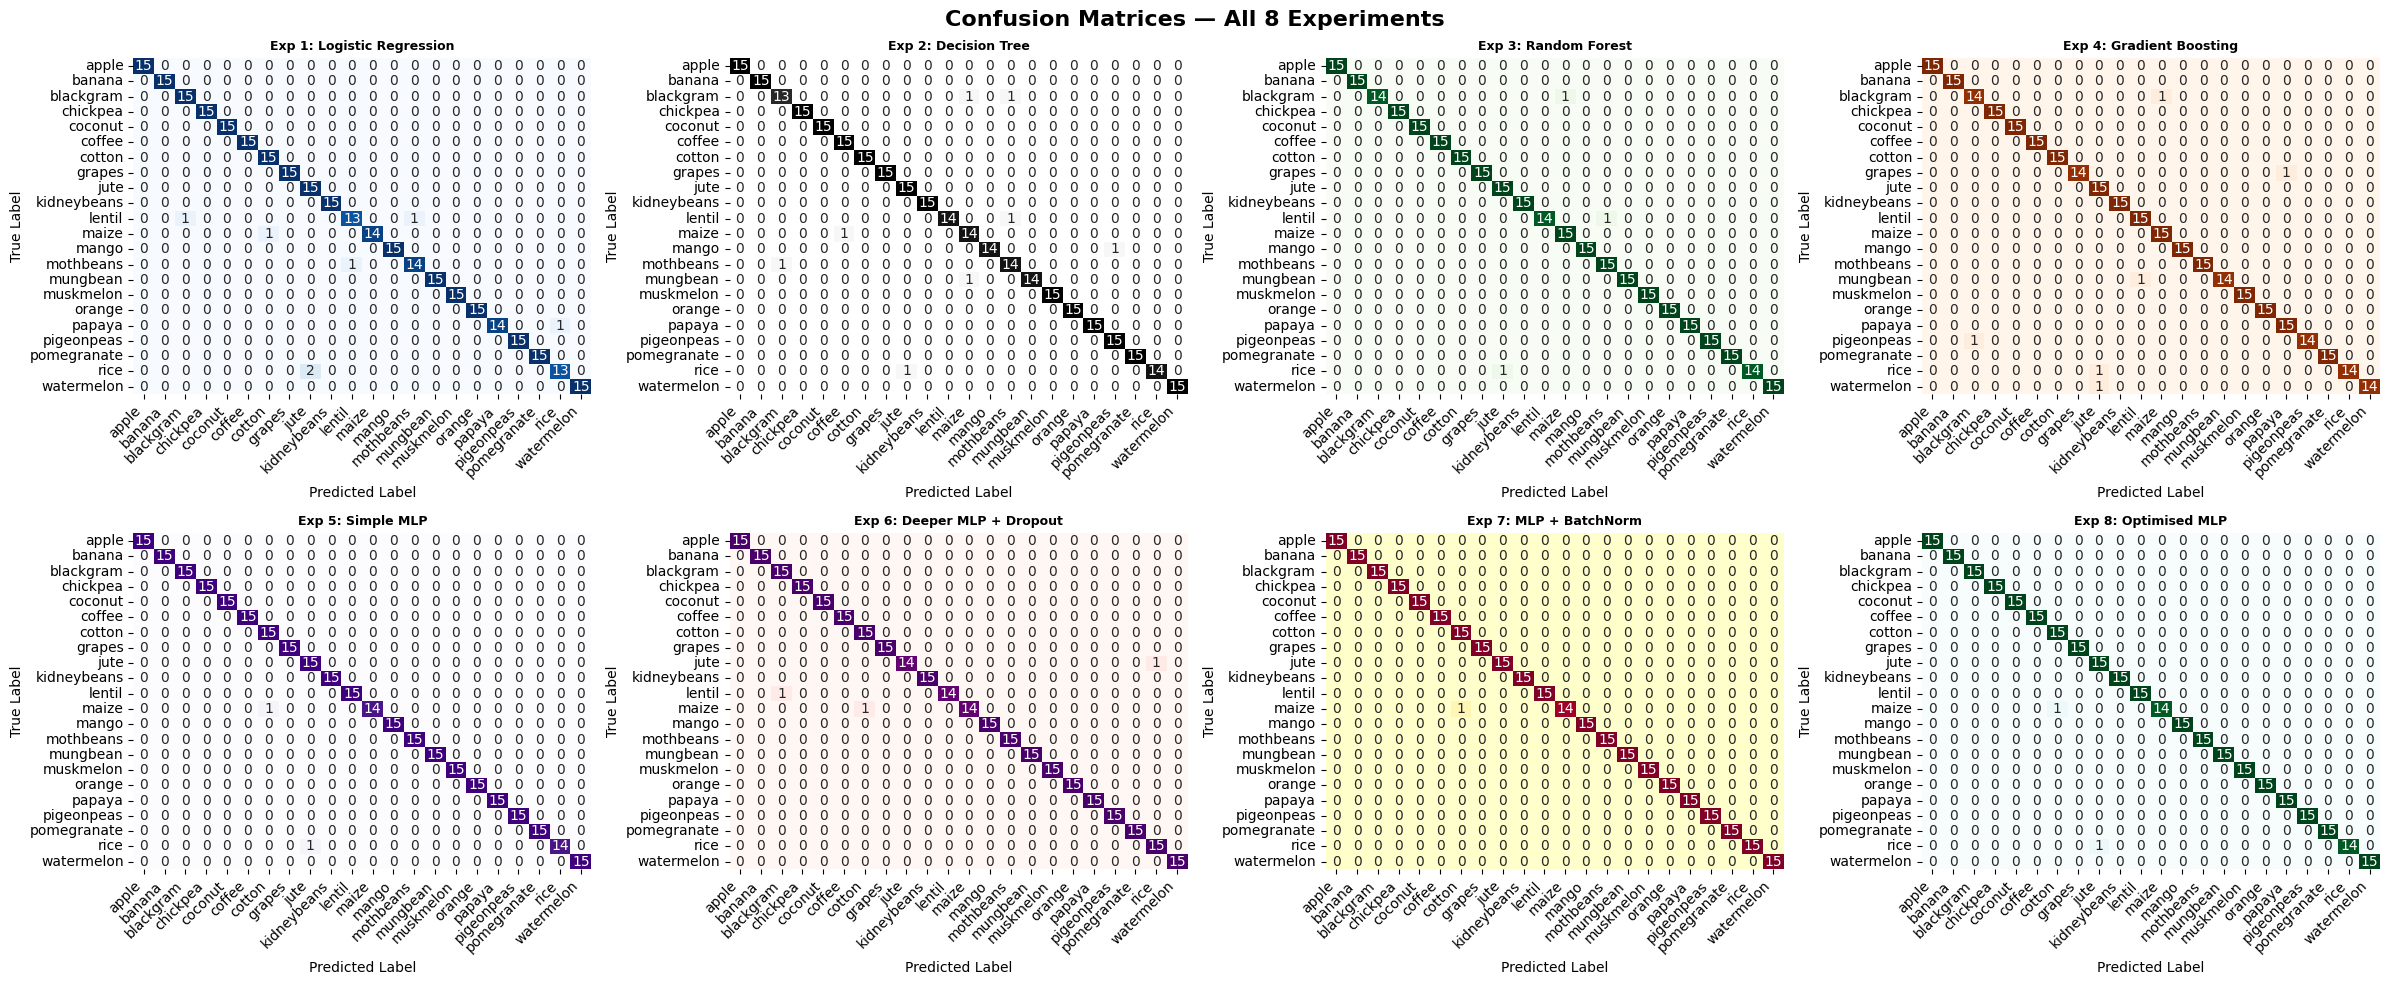

Saved as confusion_matrices.png


In [25]:
#CONFUSION MATRICES
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle("Confusion Matrices — All 8 Experiments", fontsize=16, fontweight="bold")
axes = axes.flatten()

cm_list = [
    (confusion_matrix(y_test_e, y_pred_lr),  "Exp 1: Logistic Regression",  "Blues"),
    (confusion_matrix(y_test_e, y_pred_dt),  "Exp 2: Decision Tree",         "Greys"),
    (confusion_matrix(y_test_e, y_pred_rf),  "Exp 3: Random Forest",         "Greens"),
    (confusion_matrix(y_test_e, y_pred_gb),  "Exp 4: Gradient Boosting",     "Oranges"),
    (confusion_matrix(y_test_e, y_pred_nn1), "Exp 5: Simple MLP",            "Purples"),
    (confusion_matrix(y_test_e, y_pred_nn2), "Exp 6: Deeper MLP + Dropout",  "RdPu"),
    (confusion_matrix(y_test_e, y_pred_nn3), "Exp 7: MLP + BatchNorm",       "YlOrRd"),
    (confusion_matrix(y_test_e, y_pred_nn4), "Exp 8: Optimised MLP",         "BuGn"),
]

for i, (cm, title, cmap) in enumerate(cm_list):
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=axes[i], cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(title, fontweight="bold", fontsize=9)
    axes[i].set_ylabel("True Label")
    axes[i].set_xlabel("Predicted Label")
    plt.setp(axes[i].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as confusion_matrices.png")

Learning curves

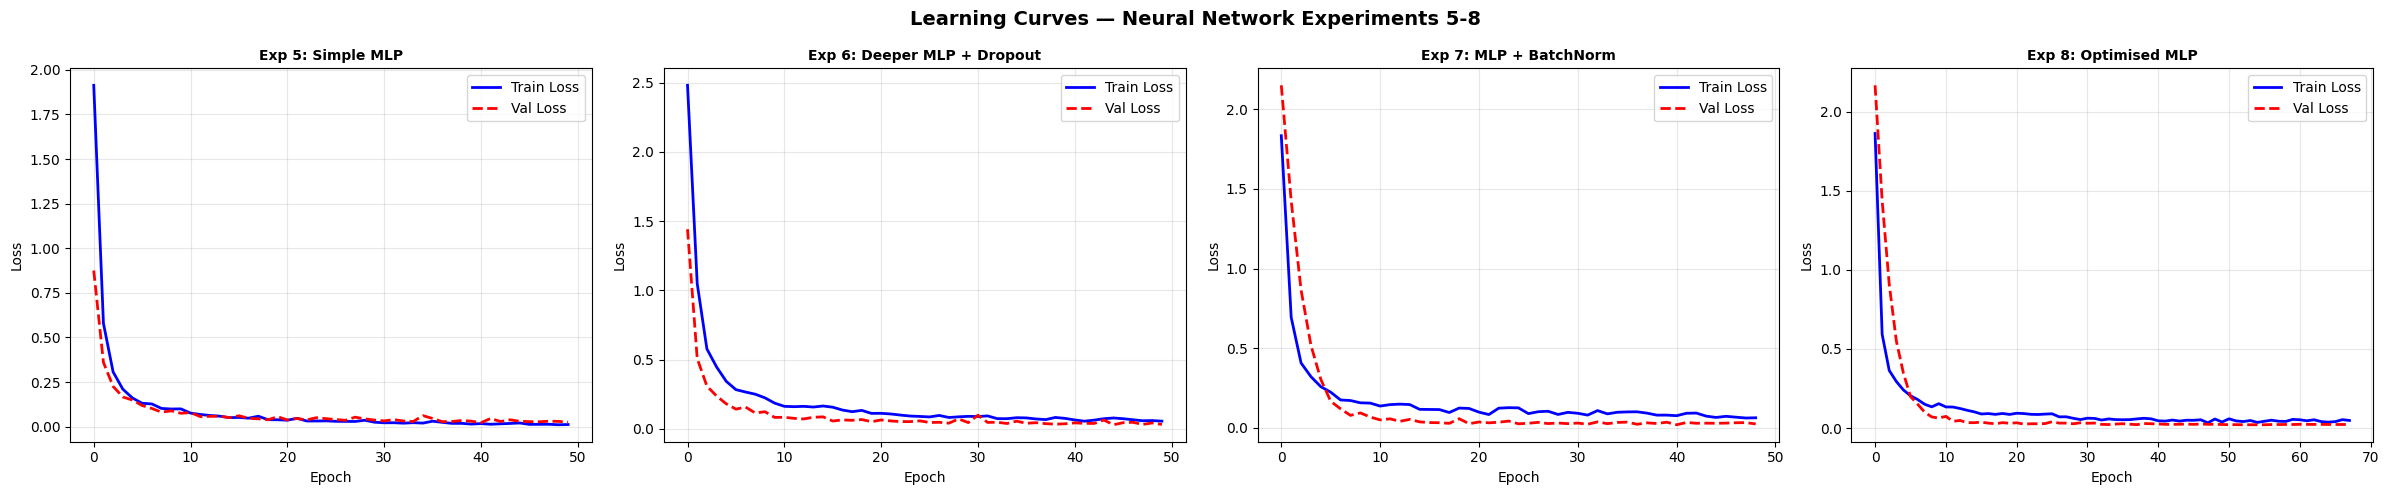

Saved as learning_curves.png


In [28]:
#LEARNING CURVES
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Learning Curves — Neural Network Experiments 5-8",
             fontsize=14, fontweight="bold")

for i, (hist, title) in enumerate([
    (history5, "Exp 5: Simple MLP"),
    (history6, "Exp 6: Deeper MLP + Dropout"),
    (history7, "Exp 7: MLP + BatchNorm"),
    (history8, "Exp 8: Optimised MLP"),
]):
    axes[i].plot(hist.history["loss"],     label="Train Loss", linewidth=2, color="blue")
    axes[i].plot(hist.history["val_loss"], label="Val Loss",   linewidth=2, color="red", linestyle="--")
    axes[i].set_title(title, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as learning_curves.png")

Results Summary

,Model,Accuracy,Precision,Recall,F1-Score,Hyperparameters,Observations
0,Exp 8: Optimised MLP (LR Schedule + Early Stop),1.0000,1.0000,1.0000,1.0000,"[256,128,64] BatchNorm+Dropout, ReduceLROnPlat...",ReduceLROnPlateau halves the learning rate whe...
1,Exp 7: MLP + BatchNorm + EarlyStopping,0.9970,0.9972,0.9970,0.9970,"[256,128,64], BatchNorm after each layer, Drop...",BatchNorm normalises activations across each m...
2,Exp 5: Simple MLP (Sequential),0.9939,0.9943,0.9939,0.9939,"2 hidden layers [256,128], ReLU, Adam lr=1e-3,...",Two-layer MLP establishes the deep learning ba...
3,Exp 8: Optimised MLP (LR Schedule + Early Stop),0.9939,0.9943,0.9939,0.9939,"[256,128,64] BatchNorm+Dropout, ReduceLROnPlat...",ReduceLROnPlateau halves the learning rate whe...
4,Exp 3: Random Forest,0.9909,0.9915,0.9909,0.9909,"n_estimators=300, max_depth=None, min_samples_...",Bagging 300 trees with random feature subsets ...
5,Exp 6: Deeper MLP + Dropout (Functional API),0.9909,0.9915,0.9909,0.9909,"3 hidden layers [256,128,64], Dropout(0.3), Ad...",Dropout randomly zeroes 30% of neurons per tra...
6,Exp 8: Optimised MLP (LR Schedule + Early Stop),0.9879,0.9890,0.9879,0.9878,"[256,128,64] BatchNorm+Dropout, ReduceLROnPlat...",ReduceLROnPlateau halves the learning rate whe...
7,Exp 4: Gradient Boosting,0.9818,0.9831,0.9818,0.9819,"n_estimators=300, learning_rate=0.05, max_dept...",Sequential boosting corrects residual errors f...
8,Exp 1: Logistic Regression,0.9788,0.9794,0.9788,0.9787,"C=1.0, max_iter=1000, solver=lbfgs + 9 enginee...",Establishes a low-capacity linear baseline. Hi...
9,Exp 2: Decision Tree,0.9758,0.9769,0.9758,0.9758,max_depth=None + 9 engineered features,Unconstrained depth allows the tree to partiti...


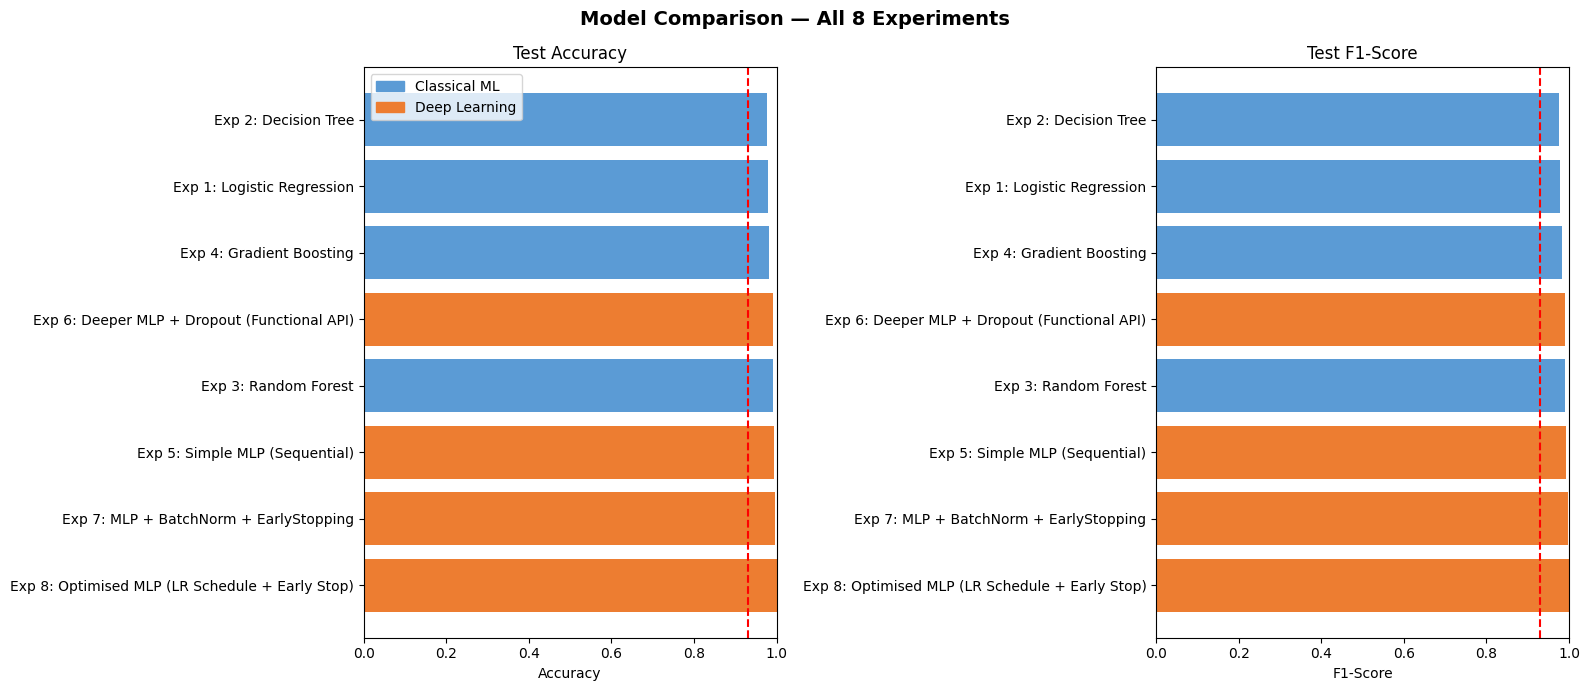

Saved as results_comparison.png


In [32]:
#RESULTS TABLE + CHART
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1-Score", ascending=False).reset_index(drop=True)
display(results_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Model Comparison — All 8 Experiments", fontsize=14, fontweight="bold")

bar_colors = []
for name in results_df["Model"]:
    if any(k in name for k in ["Logistic", "Tree", "Forest", "Boosting"]):
        bar_colors.append("#5b9bd5")
    else:
        bar_colors.append("#ed7d31")

for ax, metric in zip(axes, ["Accuracy", "F1-Score"]):
    ax.barh(results_df["Model"], results_df[metric], color=bar_colors)
    ax.set_xlabel(metric)
    ax.set_title(f"Test {metric}")
    ax.set_xlim(0, 1)
    ax.axvline(0.93, color="red", linestyle="--", linewidth=1.5)

from matplotlib.patches import Patch
legend_handles = [
    Patch(color="#5b9bd5", label="Classical ML"),
    Patch(color="#ed7d31", label="Deep Learning"),

]
axes[0].legend(handles=legend_handles)

plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as results_comparison.png")